# Verovio conversion to MEI

This notebook is the conversion front door for CAMAT's MEI-first parsing workflow. Verovio-supported sources convert directly; MuseScore-native sources use MuseScore to export MusicXML; and other music21-readable sources use music21 to export MusicXML. In every conversion route, Verovio produces the final MEI used for analysis.

Why this shape: MEI gives the downstream parser explicit `xml:id` anchors, which are useful for annotation, Verovio highlighting, and round-tripping selected notes back into the rendered score.

## Capability assessment

Verovio is a good conversion layer for the formats we care about most here:

- MEI input: `.mei` files pass through unchanged. MEI stored with an ambiguous `.xml` suffix is written to a final `.mei` file by Verovio.
- MusicXML input: plain `.xml` / `.musicxml` files use Verovio's MusicXML importer. Compressed `.mxl` files use Verovio's ZIP loader before MEI export.
- Humdrum/Kern input: `.krn`, `.kern`, and `.hum` text files use Verovio's Humdrum importer. Conversion quality depends on how explicit the Kern encoding is.
- MuseScore input: `.mscz` / `.mscx` files are not loaded by Verovio directly. If MuseScore Studio/CLI is installed, the helper exports MusicXML with MuseScore, then sends that MusicXML to Verovio. Without MuseScore, the report explains the missing optional system dependency.
- Other inputs: formats Verovio cannot identify, including `.mid` / `.midi`, are offered to music21. Music21 exports an intermediate MusicXML file, which Verovio converts to final MEI.

Practical limits: treat every conversion as an import/normalization step, not as a lossless archival transform. This is especially true for MIDI, where spelling, voices, notation, articulations, and meter/key structure may need review after music21 quantization. Generated IDs are stable enough for a fixed Verovio version plus fixed options, but they are not a permanent scholarly identifier across Verovio upgrades. Keep the original source and a conversion report next to every generated MEI file.

In [ ]:
# Parameters
from pathlib import Path

OUTPUT_DIR = Path("converted_mei/verovio_conversion_tests")
TIMEOUT_SECONDS = 90
RENDER_FIRST_PAGE = True
N_JOBS = -1                 # 1 = serial; >1 uses workers; -1 = os.cpu_count()
SHOW_PROGRESS = True        # tqdm progress bar
MAX_SOURCES = None          # set to a small int for a quick corpus smoke test

# Output naming controls for converted files.
# Example: OUTPUT_SUFFIX = "bach_test" -> *_verovio_bach_test.mei
OUTPUT_SUFFIX = ""
ADD_TIMESTAMP = False       # append YYYYMMDD_HHMMSS to converted filenames

# Test sources proposed for the conversion workflow.
# Local .txt files are expanded as newline-separated source lists.
# Native Verovio inputs include MEI, MusicXML/MXL, Humdrum, ABC, PAE, DARMS, EsAC, and Volpiano.
# MSCZ/MSCX conversion requires MuseScore Studio/CLI on PATH or MUSESCORE_BIN=/path/to/mscore.
# Other music21-readable formats use music21 -> MusicXML -> Verovio -> MEI.
FILE_SOURCES = [
    # "https://analyse.hfm-weimar.de/database/02/PrJode_Jos0302_COM_1-5_MissaDapac_002_00006.xml",
    # "https://raw.githubusercontent.com/humdrum-tools/bach-wtc-fugues/refs/heads/master/kern/wtc1f04.krn",
    # "https://raw.githubusercontent.com/humdrum-tools/bach-wtc/refs/heads/main/kern/wtc1f22.krn",
    # "https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/heads/main/Schubert_Winterreise_Dataset_v2-0/01_RawData/score_musicxml/Schubert_D911-20.xml",
    # "test_corpus/test_corpus_links.txt",
    # "test_corpus/small_corpus.txt",
    # Add local or remote .mxl/.mid files here when probing those import paths.
    # "test_corpus/70.mxl",
    # "test_corpus/Kinkel_Johanna_-_3_Duetten_Op.11_No.1_-_Das_Lied_der_Nachtigall_-_TEMPLATE.mxl",
    "test_corpus/Buxtehude-Anhang-S. 178.musicxml",
    "test_corpus/Buxtehude-Anhang-S. 185.musicxml"
    # "test_corpus/Keyboard_Sonata_in_B-flat_major_K.545_L.500_-_Domenico_Scarlatti.mxl",
    # "test_corpus/Lang_Josephine_-_3_Lieder_Op.8_No.2_-_In_die_Ferne.mid",
    # "test_corpus/Lang_Josephine_-_3_Lieder_Op.8_No.2_-_In_die_Ferne.musicxml",
    # "test_corpus/Lang_Josephine_-_3_Lieder_Op.8_No.2_-_In_die_Ferne.xml",
    # "test_corpus/Lang_Josephine_-_3_Lieder_Op.8_No.2_-_In_die_Ferne.mxl",
    # "test_corpus/LiFra_S141_3-6_COM_Grandesetu_001_00327.mid",
    # "test_corpus/LiFra_S141_3-6_COM_Grandesetu_001_00327.musicxml",
    # "test_corpus/LiFra_S141_3-6_COM_Grandesetu_001_00327.mxl",
    # "test_corpus/LiFra_S141_3-6_COM_Grandesetu_001_00327.xml",
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('converted_mei/verovio_conversion_tests')

## Convert and inspect

The conversion helper runs each Verovio import in a child Python process. That is deliberate: Verovio is native code, and a subprocess keeps the notebook alive if one malformed source crashes the converter. MuseScore and music21 fallback routes create intermediate MusicXML files; the report records both the route and intermediate path so the notation cleanup step is auditable.

In [ ]:
import json

import pandas as pd
from IPython.display import display

from camat import expand_file_sources
from scripts.test_verovio_conversion import convert_sources, _print_summary

expanded_file_sources = expand_file_sources(FILE_SOURCES, base_dir=Path.cwd(), verbose=True)
if MAX_SOURCES is not None:
    expanded_file_sources = expanded_file_sources[:MAX_SOURCES]
print(f"Converting {len(expanded_file_sources)} source(s).")

records = convert_sources(
    expanded_file_sources,
    output_dir=OUTPUT_DIR,
    timeout=TIMEOUT_SECONDS,
    render_first_page=RENDER_FIRST_PAGE,
    n_jobs=N_JOBS,
    output_suffix=OUTPUT_SUFFIX,
    timestamp=ADD_TIMESTAMP,
    show_progress=SHOW_PROGRESS,
    expand_txt_sources=False,
)

report_path = OUTPUT_DIR / "conversion_report.json"
report_path.write_text(json.dumps(records, indent=2), encoding="utf-8")

conversion_df = pd.DataFrame(records)
_print_summary(records)

display_cols = [
    "status",
    "input_from",
    "converted",
    "overwritten",
    "page_count",
    "measure_count",
    "note_count",
    "rest_count",
    "xml_id_count",
    "duplicate_xml_id_count",
    "svg_ok",
    "verovio_version",
    "output_mei",
    "message",
    "error",
]
display(conversion_df[[c for c in display_cols if c in conversion_df.columns]])
print(f"Report written to: {report_path}")

Converting 2 source(s).


Converting with Verovio:   0%|          | 0/2 [00:00<?, ?file/s]


=== Verovio Conversion Capability Probe ===

status  input        pages measures   notes  xml:id  dupe  source
-----------------------------------------------------------------
ok      musicxml         2       11     281     895     0  test_corpus/Buxtehude-Anhang-S. 178.musicxml
ok      musicxml         2       17     350    1129     0  test_corpus/Buxtehude-Anhang-S. 185.musicxml

Output paths:
  created: /home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/Buxtehude-Anhang-S._178_musicxml_verovio.mei
    source: test_corpus/Buxtehude-Anhang-S. 178.musicxml
  created: /home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/Buxtehude-Anhang-S._185_musicxml_verovio.mei
    source: test_corpus/Buxtehude-Anhang-S. 185.musicxml



,status,input_from,converted,overwritten,page_count,measure_count,note_count,rest_count,xml_id_count,duplicate_xml_id_count,svg_ok,verovio_version,output_mei,message,error
0,ok,musicxml,True,False,2,11,281,35,895,0,True,6.1.0-682d606,/home/eggi/Nextcloud/code/public_repos/camat_v...,Converted with Verovio.,None
1,ok,musicxml,True,False,2,17,350,45,1129,0,True,6.1.0-682d606,/home/eggi/Nextcloud/code/public_repos/camat_v...,Converted with Verovio.,None


Report written to: converted_mei/verovio_conversion_tests/conversion_report.json


/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/Buxtehude-Anhang-S._178_musicxml_verovio.mei


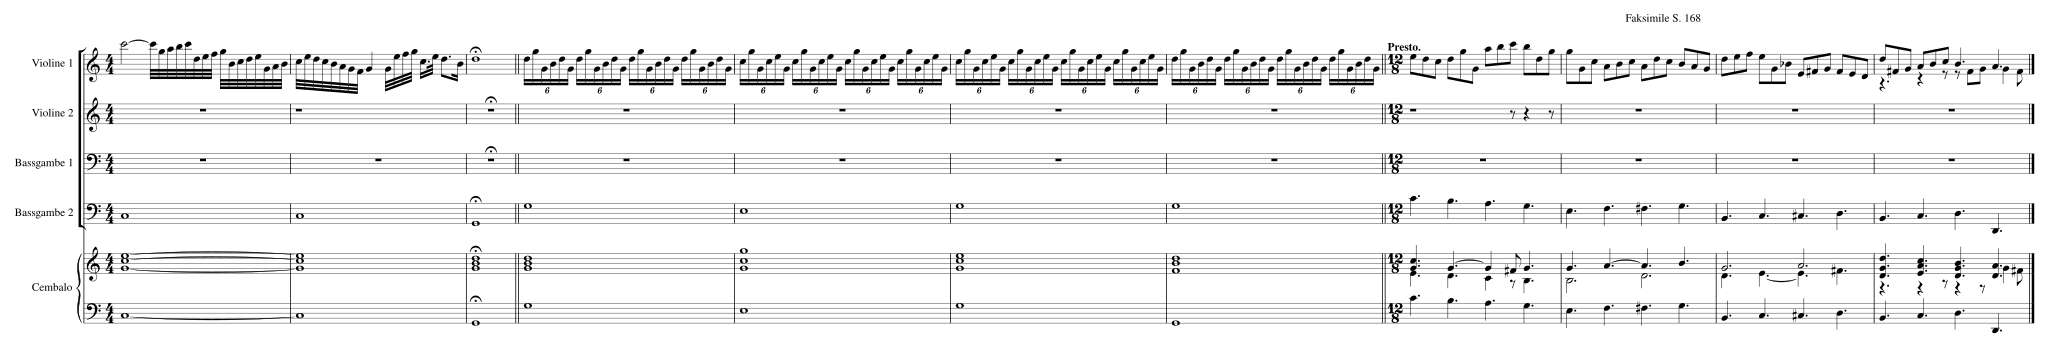

In [ ]:
# Render the first successfully converted MEI file.
from camat import vrv_display_svg, vrv_load_from_file, vrv_quiet, vrv_render_page, vrv_set_options

ok_records = [r for r in records if r.get("status") == "ok" and r.get("output_mei")]

if ok_records:
    preview_path = ok_records[0]["output_mei"]
    print(preview_path)
    with vrv_quiet():
        vrv_set_options(pageWidth=12000, pageHeight=1200, scale=40, breaks="none", removeIds=False, xmlIdSeed=0)
        vrv_load_from_file(preview_path, input_from="mei")
        vrv_display_svg(vrv_render_page(1))
else:
    print("No successful conversion to preview.")

In [ ]:
converted_sources = [r["output_mei"] for r in ok_records]

print(converted_sources)

['/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/Buxtehude-Anhang-S._178_musicxml_verovio.mei', '/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/Buxtehude-Anhang-S._185_musicxml_verovio.mei']


## Artifact design

Recommended layout:

- `converted_mei/`: generated artifacts, ignored by git.
- `converted_mei/<corpus_or_test_name>/`: one conversion batch.
- `converted_mei/<batch>/_sources/`: cached originals used for the conversion.
- `converted_mei/<batch>/conversion_report.json`: source URL, inferred input type, conversion route, intermediate MusicXML path when used, final MEI path, page count, note count, measure count, xml:id count, duplicate xml:id count, and any error.
- `converted_mei/<batch>/*.mei`: files to feed into `parse_files(...)` after a quick inspection.

Do not overwrite the source files and do not commit converted MEI by default. If a converted MEI becomes a curated fixture, move it to a deliberate fixture/test corpus path and commit it with its source URL and Verovio version in metadata or docs.

In [ ]:
# Optional: parse the converted MEI files with CAMAT's default Verovio backend.
from camat.parser_registry import parse_files

PARSE_CONVERTED_MEI = False

converted_sources = [r["output_mei"] for r in ok_records]

if PARSE_CONVERTED_MEI and converted_sources:
    results, dfs_by_name, df_processed = parse_files(
        converted_sources,
        quiet_native_warnings=True,
        print_parsed_summary=True,
        filter_zero_duration=True,
        adjust_fractional_duration=True,
        parse_enharmonic=True,
        backend="none",
        display_preview_df_pitch=True,
        display_preview_df_events=True,
        include_xml_ids=True,
        cleanup_remote=False,
        use_remote_cache=False,
        n_jobs=1,
    )
else:
    print("Set PARSE_CONVERTED_MEI = True to parse these converted MEI files:")
    for path in converted_sources:
        print(path)

Set PARSE_CONVERTED_MEI = True to parse these converted MEI files:
/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/Buxtehude-Anhang-S._178_musicxml_verovio.mei
/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/Buxtehude-Anhang-S._185_musicxml_verovio.mei


## Terminal test

The notebook reuses `scripts/test_verovio_conversion.py`. To run the same conversion probe outside Jupyter:

```bash
conda run -n py310 python scripts/test_verovio_conversion.py --n-jobs -1
```

With custom output names:

```bash
conda run -n py310 python scripts/test_verovio_conversion.py --output-suffix trial --timestamp
```

If your shell exposes a direct launcher, this is equivalent:

```bash
py310 scripts/test_verovio_conversion.py --n-jobs -1
```

To convert a newline-separated source list:

```bash
conda run -n py310 python scripts/test_verovio_conversion.py --source test_corpus/test_corpus_links.txt --n-jobs -1
```